In [15]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap
from snf import compute, make_affinity
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from lifelines import KaplanMeierFitter
import prince
import seaborn as sns

# Set a random seed for reproducibility
random_state = 492026

/Users/cromacair/Desktop/STAT 486/Final Project/.venv/lib/python3.14/site-packages/autograd/wrap_util.py:38: SyntaxWarning: 'return' in a 'finally' block
  return f


In [ ]:
# Read in the data
df = pd.read_csv('../data/raw_lung_cancer_data.csv')
df

,year_of_diagnosis,dx_lastcontact_death_months,puf_vital_status,puf_case_id,puf_facility_id,facility_type_cd,facility_location_cd,age,sex,race,...,mets_at_dx_liver,mets_at_dx_lung,mets_at_dx_other,tumor_size_summary_2016,rx_summ_surg_prim_site,rx_summ_treatment_status,rx_summ_chemo,rx_summ_immunotherapy,rx_summ_surgrad_seq,tumor_size_na
0,2018,1.120000,Dead,D00002e7d-bb34-46e6-849e-6c4f0acef147,RNYCFBVPLK,Community Cancer Program,South Atlantic,71,Male,White,...,NaN,Yes,Yes,94.0,NaN,No Treatment Given,NaN,NaN,No radiation therapy and/or surgical procedures,False
1,2019,34.070000,Dead,D00002f04-3dd7-4234-bb33-84f3a20b86c9,PSAHKJHEIG,Comprehensive Community Cancer Program,Pacific,Ninety or older,Female,Black,...,NaN,Yes,NaN,28.0,NaN,Treatment Given,NaN,"Immunotherapy recommended, unknown if administ...",No radiation therapy and/or surgical procedures,False
2,2019,21.450001,Dead,D0000690b-4418-4162-bc8e-2d62701c93ca,GQSMCSUAOK,Community Cancer Program,East North Central,80,Female,White,...,NaN,NaN,NaN,12.0,NaN,Treatment Given,Multiagent chemotherapy,NaN,No radiation therapy and/or surgical procedures,False
3,2022,1.380000,Dead,D00006b9c-dcb3-4535-a4fd-e20bd886fc9d,AUUCOIRDTB,Comprehensive Community Cancer Program,South Atlantic,80,Female,American Indian,...,NaN,NaN,Yes,87.0,NaN,Treatment Given,NaN,Immunotherapy administered as first course the...,No radiation therapy and/or surgical procedures,False
4,2019,40.049999,Alive,D00006dce-2eb8-498e-a6bc-da673b7a434e,CFHJPZWJNY,Integrated Network Cancer Program,West South Central,57,Female,White,...,NaN,NaN,NaN,NaN,NaN,Treatment Given,Multiagent chemotherapy,Immunotherapy administered as first course the...,No radiation therapy and/or surgical procedures,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501364,2020,7.360000,Dead,Dffff7a97-fd34-438d-b5b9-ca1930c78679,TXEIDOZHLI,Integrated Network Cancer Program,South Atlantic,75,Male,White,...,NaN,NaN,NaN,103.0,56.0,Treatment Given,Multiagent chemotherapy,Immunotherapy administered as first course the...,No radiation therapy and/or surgical procedures,False
501365,2018,12.160000,Dead,Dffff8d6c-a1cd-4085-9846-222b943a44d3,TVXWQGNICT,Comprehensive Community Cancer Program,Pacific,61,Female,White,...,NaN,NaN,NaN,46.0,NaN,Treatment Given,Multiagent chemotherapy,Immunotherapy administered as first course the...,No radiation therapy and/or surgical procedures,False
501366,2022,1.870000,Dead,Dffffabfc-6747-43e7-86c7-9cf043363c9f,UMUHJVXWPB,Integrated Network Cancer Program,West South Central,75,Male,Other,...,NaN,Yes,NaN,NaN,NaN,No Treatment Given,NaN,NaN,No radiation therapy and/or surgical procedures,True
501367,2018,38.410000,Alive,Dffffac4c-3b09-40a9-bfb0-45bd6333893d,JDTRSDGOHO,Community Cancer Program,West South Central,70,Male,White,...,Yes,NaN,NaN,32.0,12.0,Treatment Given,NaN,NaN,Radiation therapy after surgery,False


In [3]:
# For 'age', calculate the mean, standard deviation, median, interquartile range (IQR), and range (min–max)
df['age'] = df['age'].replace('Ninety or older', 90).astype(float)
age_mean = round(df['age'].mean(), 2)
age_std = round(df['age'].std(), 2)
age_median = df['age'].median()
age_q3 = df['age'].quantile(0.75)
age_q1 = df['age'].quantile(0.25)
age_range = df['age'].max() - df['age'].min()
print(f"Age Mean: {age_mean}")
print(f"Age Standard Deviation: {age_std}")
print(f"Age Median: {age_median}")
print(f"Age Q3: {age_q3}")
print(f"Age Q1: {age_q1}")
print(f"Age Range: {age_range}")

Age Mean: 69.57
Age Standard Deviation: 9.64
Age Median: 70.0
Age Q3: 77.0
Age Q1: 63.0
Age Range: 50.0


In [4]:
# For 'tumor_size_summary_2016', calculate the mean, standard deviation, median, interquartile range (IQR),
# and range (min–max)
df['tumor_size_summary_2016'] = df['tumor_size_summary_2016'].replace('No Tumor found', 0)
df['tumor_size_summary_2016'] = df['tumor_size_summary_2016'].replace('1 mm or < 1 mm', 1)
df['tumor_size_summary_2016'] = df['tumor_size_summary_2016'].replace('>=989 mm', 989)
df['tumor_size_summary_2016'] = df['tumor_size_summary_2016'].replace('Site Specific Codes', np.nan)
df['tumor_size_summary_2016'] = df['tumor_size_summary_2016'].replace(
    'Microscopic focus/foci only/no size of focus', 0).astype(float)
tumor_size_mean = round(df['tumor_size_summary_2016'].mean(), 2)
tumor_size_std = round(df['tumor_size_summary_2016'].std(), 2)
tumor_size_median = df['tumor_size_summary_2016'].median()
tumor_size_q3 = df['tumor_size_summary_2016'].quantile(0.75)
tumor_size_q1 = df['tumor_size_summary_2016'].quantile(0.25)
tumor_size_range = df['tumor_size_summary_2016'].max() - df['tumor_size_summary_2016'].min()
print(f"Tumor Size Mean: {tumor_size_mean}")
print(f"Tumor Size Standard Deviation: {tumor_size_std}")
print(f"Tumor Size Median: {tumor_size_median}")
print(f"Tumor Size Q3: {tumor_size_q3}")
print(f"Tumor Size Q1: {tumor_size_q1}")
print(f"Tumor Size Range: {tumor_size_range}")

Tumor Size Mean: 37.71
Tumor Size Standard Deviation: 35.19
Tumor Size Median: 30.0
Tumor Size Q3: 50.0
Tumor Size Q1: 18.0
Tumor Size Range: 989.0


In [5]:
# For 'dx_lastcontact_death_months', calculate the mean, standard deviation, median,
# interquartile range (IQR), and range (min–max) for the subset of patients who died of lung cancer
df_dead = df[df['puf_vital_status'] == 'Dead']
surv_time_mean = round(df_dead['dx_lastcontact_death_months'].mean(), 2)
surv_time_std = round(df_dead['dx_lastcontact_death_months'].std(), 2)
surv_time_median = df_dead['dx_lastcontact_death_months'].median()
surv_time_q3 = df_dead['dx_lastcontact_death_months'].quantile(0.75)
surv_time_q1 = df_dead['dx_lastcontact_death_months'].quantile(0.25)
surv_time_range = df_dead['dx_lastcontact_death_months'].max() - df_dead['dx_lastcontact_death_months'].min()
print(f"Survival Time Mean: {surv_time_mean}")
print(f"Survival Time Standard Deviation: {surv_time_std}")
print(f"Survival Time Median: {round(surv_time_median, 2)}")
print(f"Survival Time Q3: {round(surv_time_q3, 2)}")
print(f"Survival Time Q1: {round(surv_time_q1, 2)}")
print(f"Survival Time Range: {round(surv_time_range, 2)}")

Survival Time Mean: 14.14
Survival Time Standard Deviation: 15.06
Survival Time Median: 8.51
Survival Time Q3: 20.67
Survival Time Q1: 2.73
Survival Time Range: 86.8


In [6]:
# For 'sex', print a table of counts and percentages for each sex
sex_counts = df['sex'].value_counts(dropna=False)
sex_percentages = round(df['sex'].value_counts(normalize=True, dropna=False) * 100, 2)
sex_table = pd.DataFrame({'Count': sex_counts, 'Percentage': sex_percentages})
print(sex_table)

         Count  Percentage
sex                       
Female  253951       50.65
Male    247418       49.35


In [7]:
# For 'analytic_stage_group', print a table of counts and percentages for each stage group
stage_counts = df['analytic_stage_group'].value_counts(dropna=False)
stage_percentages = round(df['analytic_stage_group'].value_counts(normalize=True, dropna=False) * 100, 2)
stage_table = pd.DataFrame({'Count': stage_counts, 'Percentage': stage_percentages})
print(stage_table)

                              Count  Percentage
analytic_stage_group                           
Stage IV                     173554       34.62
Stage I                      161450       32.20
Stage III                     90386       18.03
Stage II                      45889        9.15
AJCC Staging not applicable   18030        3.60
AJCC Stage Group unknown      11399        2.27
Stage 0                         444        0.09
Occult (lung only)              217        0.04


In [8]:
# For 'cdcc_total_best', print a table of counts and percentages for each comorbidity score
cdcc_counts = df['cdcc_total_best'].value_counts(dropna=False)
cdcc_percentages = round(df['cdcc_total_best'].value_counts(normalize=True, dropna=False) * 100, 2)
cdcc_table = pd.DataFrame({'Count': cdcc_counts, 'Percentage': cdcc_percentages})
print(cdcc_table)

                  Count  Percentage
cdcc_total_best                    
0                286978       57.24
1                116131       23.16
2                 51938       10.36
>=3               46322        9.24


In [9]:
# Calculate a correlation matrix for the numeric variables in the dataset ('age', crowfly',
# 'tumor_size_summary_2016', and 'dx_lastcontact_death_months')
numeric_df = df[['age', 'crowfly', 'tumor_size_summary_2016']]
numeric_df['dx_lastcontact_death_months'] = df_dead['dx_lastcontact_death_months']
correlation_matrix = numeric_df.corr()
print(round(correlation_matrix, 3))

                               age  crowfly  tumor_size_summary_2016  \
age                          1.000   -0.016                   -0.020   
crowfly                     -0.016    1.000                   -0.007   
tumor_size_summary_2016     -0.020   -0.007                    1.000   
dx_lastcontact_death_months -0.031    0.012                   -0.164   

                             dx_lastcontact_death_months  
age                                               -0.031  
crowfly                                            0.012  
tumor_size_summary_2016                           -0.164  
dx_lastcontact_death_months                        1.000  


In [10]:
# Impute missing values for 'tumor_size_summary_2016'
np.random.seed(random_state)
missing = df['tumor_size_summary_2016'].isna()
n_missing = missing.sum()
observed_values = df.loc[~missing, 'tumor_size_summary_2016']
imputed_values = np.random.choice(observed_values, size=n_missing, replace=True)
df.loc[missing, 'tumor_size_summary_2016'] = imputed_values

# Set any missing values in categorical columns to 'Unknown'
df['ur_cd_23'] = df['ur_cd_23'].fillna('Unknown')
df['mets_at_dx_bone'] = df['mets_at_dx_bone'].fillna('None')
df['mets_at_dx_brain'] = df['mets_at_dx_brain'].fillna('None')
df['mets_at_dx_distant_ln'] = df['mets_at_dx_distant_ln'].fillna('None')
df['mets_at_dx_liver'] = df['mets_at_dx_liver'].fillna('None')
df['mets_at_dx_lung'] = df['mets_at_dx_lung'].fillna('None')
df['mets_at_dx_other'] = df['mets_at_dx_other'].fillna('None')
df['rx_summ_surg_prim_site'] = df['rx_summ_surg_prim_site'].fillna('None')
df['rx_summ_chemo'] = df['rx_summ_chemo'].fillna('None')
df['rx_summ_immunotherapy'] = df['rx_summ_immunotherapy'].fillna('None')

In [11]:
# Peform block-wise dimensionality reduction

# Define blocks
block_A = ['age', 'sex', 'race', 'spanish_hispanic_origin', 
           'insurance_status', 'no_hsd_quar_2020', 'med_inc_quar_2020', 
           'ur_cd_23', 'crowfly']

block_C = ['primary_site', 'laterality', 'histology', 'lymph_vascular_invasion']

block_D = ['regional_nodes_positive', 'analytic_stage_group',
           'mets_at_dx_bone','mets_at_dx_brain','mets_at_dx_distant_ln',
           'mets_at_dx_liver','mets_at_dx_lung','mets_at_dx_other',
           'tumor_size_na', 'tumor_size_summary_2016']

block_E = ['rx_summ_surg_prim_site', 'rx_summ_treatment_status',
           'rx_summ_chemo', 'rx_summ_immunotherapy', 'rx_summ_surgrad_seq']

famd_results = {}
pca_results = {}
mca_results = {}

# ---- Block A: Mixed (numeric + categorical) -> FAMD ----
famd = prince.FAMD(n_components=4, random_state=random_state)
famd = famd.fit(df[block_A])
famd_results['block_A'] = famd.transform(df[block_A])
explained_variance_ratio = famd.eigenvalues_ / sum(famd.eigenvalues_)
print("Block A: Explained variance ratio per component:", explained_variance_ratio)
print("Block A: Cumulative explained variance:", np.cumsum(explained_variance_ratio), '\n')

# ---- Block C: Mostly categorical -> MCA ----
mca = prince.MCA(n_components=4, random_state=random_state)
mca = mca.fit(df[block_C])
mca_results['block_C'] = mca.transform(df[block_C])
explained_variance_ratio = mca.eigenvalues_ / sum(mca.eigenvalues_)
print("Block C: Explained variance ratio per component:", explained_variance_ratio)
print("Block C: Cumulative explained variance:", np.cumsum(explained_variance_ratio), '\n')

# ---- Block D: Mixed numeric & categorical -> FAMD ----
famd_D = prince.FAMD(n_components=4, random_state=random_state)
famd_D = famd_D.fit(df[block_D])
famd_results['block_D'] = famd_D.transform(df[block_D])
explained_variance_ratio = famd_D.eigenvalues_ / sum(famd_D.eigenvalues_)
print("Block D: Explained variance ratio per component:", explained_variance_ratio)
print("Block D: Cumulative explained variance:", np.cumsum(explained_variance_ratio), "\n")

# ---- Block E: Categorical -> MCA ----
mca_E = prince.MCA(n_components=4, random_state=random_state)
mca_E = mca_E.fit(df[block_E])
mca_results['block_E'] = mca_E.transform(df[block_E])
explained_variance_ratio = mca_E.eigenvalues_ / sum(mca_E.eigenvalues_)
print("Block E: Explained variance ratio per component:", explained_variance_ratio)
print("Block E: Cumulative explained variance:", np.cumsum(explained_variance_ratio), '\n')

# ---- Combine reduced blocks ----
reduced_blocks = [
    famd_results['block_A'].values,
    mca_results['block_C'].values,
    famd_results['block_D'].values,
    mca_results['block_E'].values
]

X_reduced = np.hstack(reduced_blocks)

print("Final reduced dataset shape:", X_reduced.shape)


# Combine reduced blocks into a single DataFrame with appropriate column names
reduced_column_names = ['block_A_comp1', 'block_A_comp2', 'block_A_comp3', 'block_A_comp4',
                        'block_C_comp1', 'block_C_comp2', 'block_C_comp3', 'block_C_comp4',
                        'block_D_comp1', 'block_D_comp2', 'block_D_comp3', 'block_D_comp4',
                        'block_E_comp1', 'block_E_comp2', 'block_E_comp3', 'block_E_comp4']
df_block_comps = pd.DataFrame(X_reduced, columns=reduced_column_names)
cols_to_add = ['year_of_diagnosis',
                'dx_lastcontact_death_months',
                'puf_vital_status',
                'puf_case_id',
                'puf_facility_id',
                'facility_type_cd',
                'facility_location_cd',
                'cdcc_total_best']
df_other = df[cols_to_add].reset_index(drop=True)
df_reduced = pd.concat([df_other, df_block_comps], axis=1)
df_reduced

Block A: Explained variance ratio per component: [0.335912   0.25802141 0.21070273 0.19536386]
Block A: Cumulative explained variance: [0.335912   0.59393341 0.80463614 1.        ] 

Block C: Explained variance ratio per component: [0.32983748 0.27631567 0.2105228  0.18332405]
Block C: Cumulative explained variance: [0.32983748 0.60615315 0.81667595 1.        ] 

Block D: Explained variance ratio per component: [0.45543957 0.21277145 0.17068618 0.16110281]
Block D: Cumulative explained variance: [0.45543957 0.66821102 0.83889719 1.        ] 

Block E: Explained variance ratio per component: [0.28709551 0.27373352 0.23145739 0.20771359]
Block E: Cumulative explained variance: [0.28709551 0.56082902 0.79228641 1.        ] 

Final reduced dataset shape: (501369, 16)


,year_of_diagnosis,dx_lastcontact_death_months,puf_vital_status,puf_case_id,puf_facility_id,facility_type_cd,facility_location_cd,cdcc_total_best,block_A_comp1,block_A_comp2,...,block_C_comp3,block_C_comp4,block_D_comp1,block_D_comp2,block_D_comp3,block_D_comp4,block_E_comp1,block_E_comp2,block_E_comp3,block_E_comp4
0,2018,1.120000,Dead,D00002e7d-bb34-46e6-849e-6c4f0acef147,RNYCFBVPLK,Community Cancer Program,South Atlantic,0,0.500864,-3.691957,...,-0.781348,-0.126614,-4.670963,-0.773314,-0.632180,-0.302161,0.193402,-0.780783,0.420136,-0.143014
1,2019,34.070000,Dead,D00002f04-3dd7-4234-bb33-84f3a20b86c9,PSAHKJHEIG,Comprehensive Community Cancer Program,Pacific,0,-2.756128,3.338512,...,0.259919,1.478465,-2.460815,-0.588895,-0.195789,-0.538804,0.893865,0.561341,0.043325,0.133538
2,2019,21.450001,Dead,D0000690b-4418-4162-bc8e-2d62701c93ca,GQSMCSUAOK,Community Cancer Program,East North Central,0,0.092933,-3.611657,...,-0.409977,0.340892,1.681292,2.548002,-0.428627,-0.948834,-0.165984,0.290728,0.070397,-0.031264
3,2022,1.380000,Dead,D00006b9c-dcb3-4535-a4fd-e20bd886fc9d,AUUCOIRDTB,Comprehensive Community Cancer Program,South Atlantic,0,-0.067411,-1.815356,...,-0.781348,-0.126614,-2.594222,-0.374956,-0.560854,0.201659,-0.200660,0.292619,0.120424,-0.065130
4,2019,40.049999,Alive,D00006dce-2eb8-498e-a6bc-da673b7a434e,CFHJPZWJNY,Integrated Network Cancer Program,West South Central,1,-0.553823,1.635874,...,-0.435174,-0.200266,0.232467,3.495110,-2.621349,0.173722,-0.420726,0.835034,0.284463,-0.123898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501364,2020,7.360000,Dead,Dffff7a97-fd34-438d-b5b9-ca1930c78679,TXEIDOZHLI,Integrated Network Cancer Program,South Atlantic,0,1.465196,-3.165007,...,0.635238,-0.176751,3.127045,1.336032,-0.002134,-1.290996,-0.491182,0.984972,-0.073397,-0.030550
501365,2018,12.160000,Dead,Dffff8d6c-a1cd-4085-9846-222b943a44d3,TVXWQGNICT,Comprehensive Community Cancer Program,Pacific,1,4.688807,5.451021,...,-0.435174,-0.200266,-2.334271,-0.392542,0.679892,-0.295198,-0.420726,0.835034,0.284463,-0.123898
501366,2022,1.870000,Dead,Dffffabfc-6747-43e7-86c7-9cf043363c9f,UMUHJVXWPB,Integrated Network Cancer Program,West South Central,>=3,-3.678127,5.770936,...,0.442119,0.107382,-6.301494,0.049167,-0.971638,0.276866,0.193402,-0.780783,0.420136,-0.143014
501367,2018,38.410000,Alive,Dffffac4c-3b09-40a9-bfb0-45bd6333893d,JDTRSDGOHO,Community Cancer Program,West South Central,0,1.529562,0.236247,...,0.800843,-0.156280,-5.051754,-1.619181,2.338264,-0.279134,-0.206463,0.474921,-0.911740,0.341521


In [12]:
df = df_reduced.copy()

In [13]:
# Create a UMAP plot of all features in the dataset colored by 'puf_vital_status'

numeric_cols = ['block_A_comp1', 'block_A_comp2', 'block_A_comp3', 'block_A_comp4', 'block_C_comp1',
                'block_C_comp2', 'block_C_comp3', 'block_C_comp4', 'block_D_comp1', 'block_D_comp2',
                'block_D_comp3', 'block_D_comp4', 'block_E_comp1', 'block_E_comp2', 'block_E_comp3',
                'block_E_comp4']
categorical_cols = ['facility_type_cd', 'facility_location_cd', 'cdcc_total_best']

# Normalize numeric features to [0,1]
X_numeric = (df[numeric_cols] - df[numeric_cols].min()) / (df[numeric_cols].max() - df[numeric_cols].min())
X_categorical = pd.get_dummies(df[categorical_cols])

X_combined = np.hstack([X_numeric.values, X_categorical.values])

reducer = umap.UMAP(metric='hamming', n_neighbors=15, min_dist=0.1, random_state=random_state)
embedding = reducer.fit_transform(X_combined)

/Users/cromacair/Desktop/STAT 486/Final Project/.venv/lib/python3.14/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/Users/cromacair/Desktop/STAT 486/Final Project/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


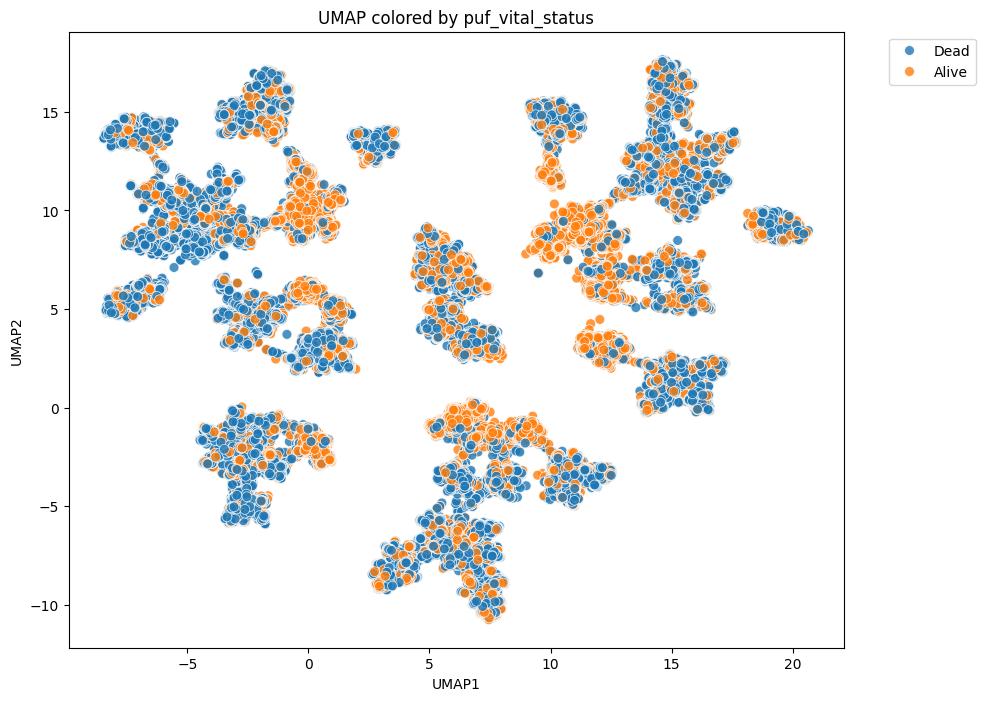

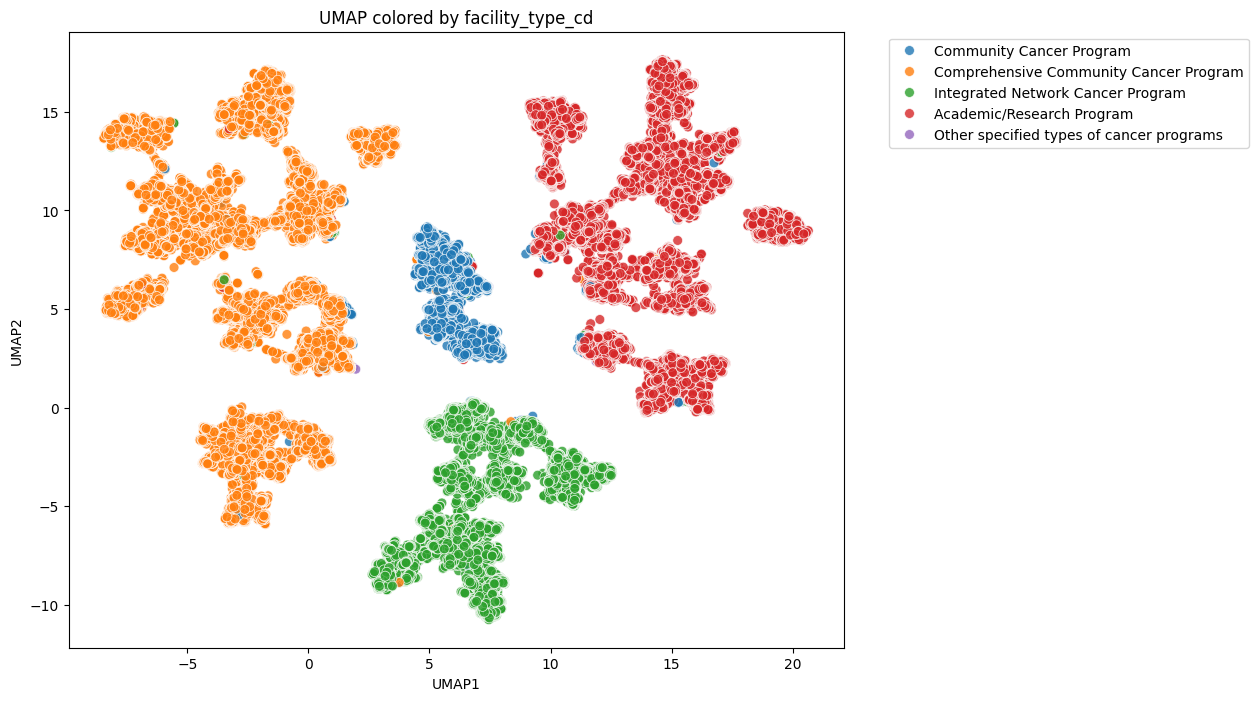

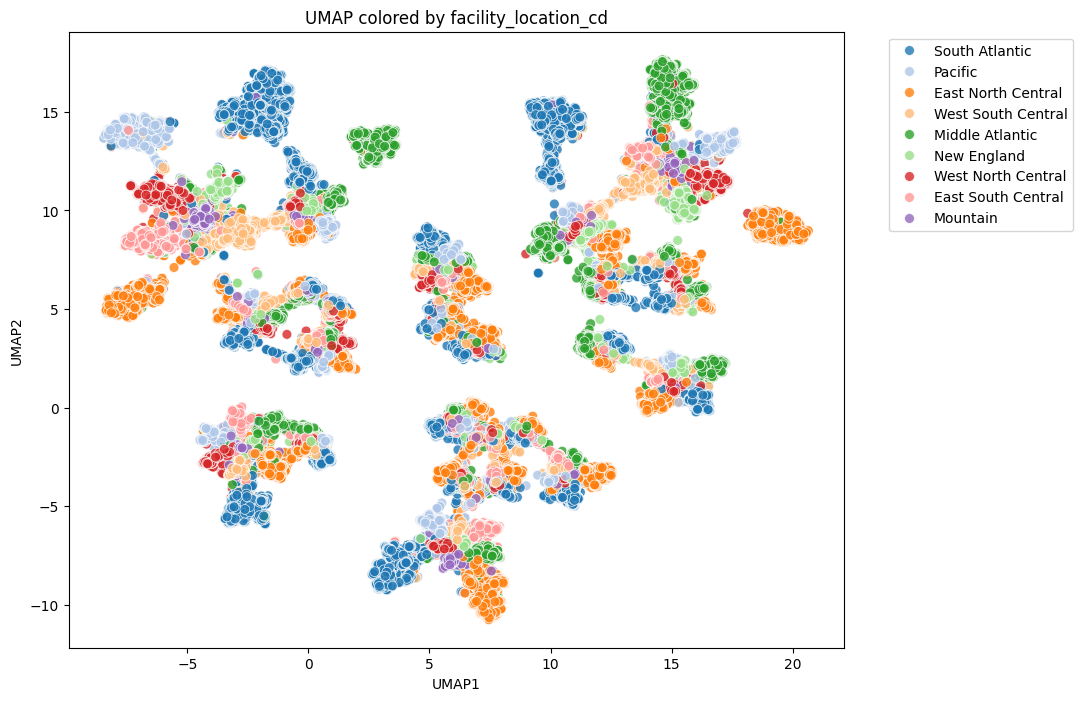

In [14]:
# Create a DataFrame for plotting
umap_df = pd.DataFrame({
    'UMAP1': embedding[:, 0],
    'UMAP2': embedding[:, 1],
    'puf_vital_status': df['puf_vital_status'],
    'facility_type_cd': df['facility_type_cd'],
    'facility_location_cd': df['facility_location_cd']
})

# Color by puf_vital_status
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='UMAP1', y='UMAP2',
    hue='puf_vital_status',
    palette='tab10',
    data=umap_df,
    s=50,
    alpha=0.8
)
plt.title('UMAP colored by puf_vital_status')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Color by facility_type_cd
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='UMAP1', y='UMAP2',
    hue='facility_type_cd',
    palette='tab10',
    data=umap_df,
    s=50,
    alpha=0.8
)
plt.title('UMAP colored by facility_type_cd')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Color by facility_location_cd
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='UMAP1', y='UMAP2',
    hue='facility_location_cd',
    palette='tab20',
    data=umap_df,
    s=50,
    alpha=0.8
)
plt.title('UMAP colored by facility_location_cd')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

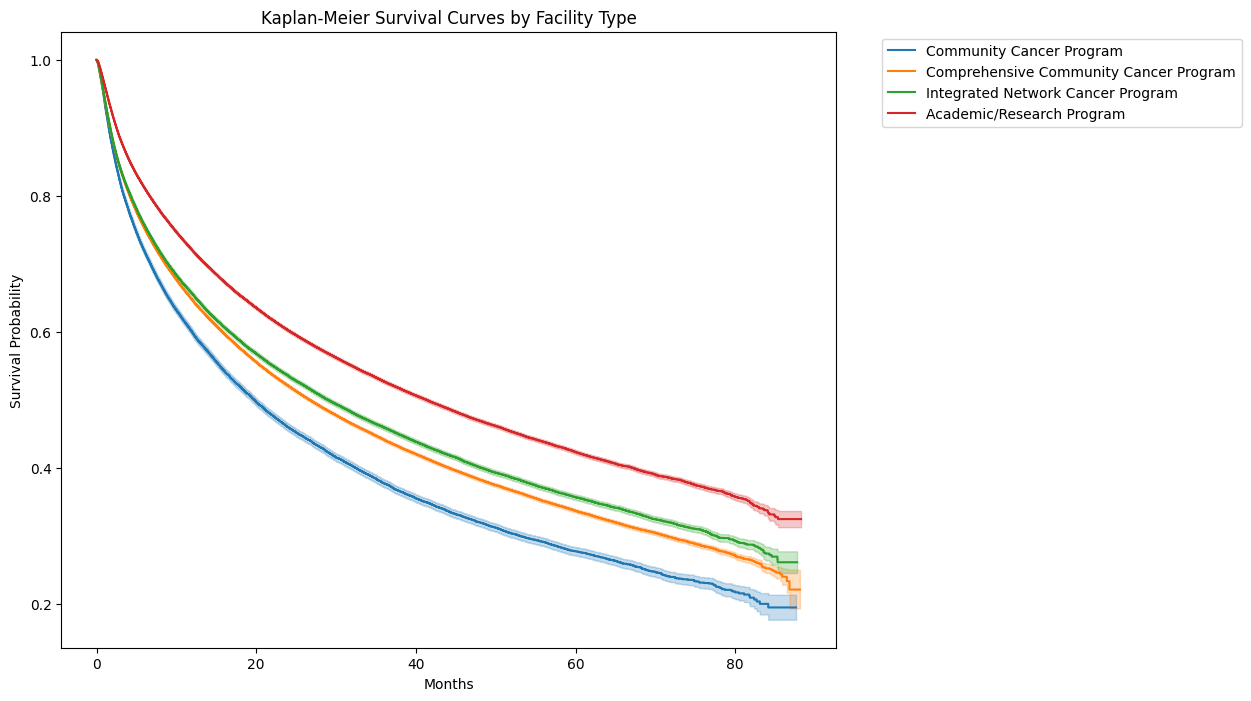

In [32]:
# Create Kaplan-Meier survival curves for different facility types
kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 8))
for facility_type in df['facility_type_cd'].unique():
    if facility_type == 'Other specified types of cancer programs':
        continue   # Skip this category due to small sample size
    else:
        mask = df['facility_type_cd'] == facility_type
        kmf.fit(df.loc[mask, 'dx_lastcontact_death_months'],
                event_observed=df.loc[mask, 'puf_vital_status'] == 1, label=facility_type)
        kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curves by Facility Type')
plt.xlabel('Months')
plt.ylabel('Survival Probability')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [33]:
                    ### WARNING ###
#########################################################################
##########   DO NOT RUN: MEMORY INTENSIVE, KERNEL WILL CRASH   ##########
#########################################################################

# # Perform similarity network fusion (SNF) on the reduced blocks

# # Example: assume df_final contains the reduced dataset
# blocks = {
#     'block_A': ['block_A_comp1', 'block_A_comp2', 'block_A_comp3', 'block_A_comp4'],
#     'block_C': ['block_C_comp1', 'block_C_comp2', 'block_C_comp3', 'block_C_comp4'],
#     'block_D': ['block_D_comp1', 'block_D_comp2', 'block_D_comp3', 'block_D_comp4'],
#     'block_E': ['block_E_comp1', 'block_E_comp2', 'block_E_comp3', 'block_E_comp4']
# }

# # Include categorical columns as one-hot
# categorical_cols = ['facility_type_cd', 'facility_location_cd', 'cdcc_total_best']
# df_categorical = pd.get_dummies(df[categorical_cols])

# # Convert each block into a separate view
# views = []
# for name, cols in blocks.items():
#     views.append(df[cols].values)
    
# # Add categorical one-hot view
# views.append(df_categorical.values)


# # Compute similarity networks
# def make_affinity_manual(X, K=20, mu=0.5):
#     """
#     Compute KNN Gaussian affinity matrix for view X
#     """
#     # Compute pairwise Euclidean distances
#     D = pairwise_distances(X, metric='euclidean')
    
#     # Compute local scaling (sigma) for each row
#     sorted_D = np.sort(D, axis=1)
#     sigma = np.mean(sorted_D[:, 1:K+1], axis=1)  # ignore self-distance
    
#     # Compute Gaussian kernel
#     W = np.exp(-(D**2) / (2 * (sigma[:, None] * sigma[None, :]) * mu**2))
    
#     # Keep only K-nearest neighbors per row
#     for i in range(X.shape[0]):
#         neighbors = np.argsort(D[i])[:K+1]  # include self
#         mask = np.ones(D.shape[1], dtype=bool)
#         mask[neighbors] = False
#         W[i, mask] = 0
    
#     return W

# affinity_matrices = []
# for view in views:
#     # Compute pairwise similarity
#     W = make_affinity_manual(view, K=20, mu=0.5)
#     affinity_matrices.append(W)


# # Fuse networks
# W_fused = compute.snf(affinity_matrices, K=20, t=20)
# print("Fused network shape:", W_fused.shape)

# # Spectral clustering on fused network
# for n_clusters in range(2, 10):
#     sc = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=42)
#     labels = sc.fit_predict(W_fused)
#     score = silhouette_score(W_fused, labels, metric='precomputed')
#     print(f'n_clusters={n_clusters}, silhouette={score:.3f}')

# # n_clusters = 3  # choose based on your data
# # clustering = SpectralClustering(
# #     n_clusters=n_clusters,
# #     affinity='precomputed',
# #     random_state=42
# # )
# # labels = clustering.fit_predict(W_fused)
# # df['SNF_cluster'] = labels
# # print(df[['puf_case_id', 'SNF_cluster']].head())